In [1]:
%load_ext dotenv
%dotenv

In [3]:
import os
#from huggingface_hub import login
#login(os.getenv('HUGGING_FACE_TOKEN'))

## 1.1 Loading the Dataset

In [4]:
from datasets import Dataset, Features, Image as HFImage
from PIL import Image

image_dir = 'data/images'
mask_dir = 'data/masks'

image_stems = {os.path.splitext(f)[0] for f in os.listdir(image_dir)}
mask_stems = {os.path.splitext(f)[0] for f in os.listdir(mask_dir)}

# keeps only the files which have masks
common_stems = sorted(image_stems & mask_stems)

def load_example(stem):
    return {
        "image": os.path.join(image_dir, f"{stem}.png"),
        "label": os.path.join(mask_dir, f"{stem}.png"),
    }

features = Features({
    "image": HFImage(),
    "label": HFImage()
})


dataset = Dataset.from_list([load_example(s) for s in common_stems])\
                 .cast(features)\
                 .train_test_split(test_size=0.1)
dataset

Casting the dataset: 100%|██████████| 148/148 [00:00<00:00, 24419.06 examples/s]


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 133
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 15
    })
})

In [5]:
missing_masks = image_stems - mask_stems
print(f"Images without masks: {len(missing_masks)}")

Images without masks: 652


## 1.2 Visualization

In [8]:
from model_common import *
from matplotlib import pyplot as plt
from matplotlib import patches
import numpy as np
   
def show_examples():
    for i in range(4):
        image = dataset['train'][i]['image']
        mask  = dataset['train'][i]['label']

        image_np = np.asarray(image)
        mask_np = np.asarray(mask)
        
        fig, ax = plt.subplots(1, 3, figsize=(18, 6))

        # Show the original image
        ax[0].imshow(image_np)
        ax[0].set_title('Original Image')
        ax[0].axis('off')
        
        # Create a new empty RGB image
        colored_mask = np.zeros(
            (mask_np.shape[0], mask_np.shape[1], 3), 
            dtype=np.uint8
        )

        # Assign colors to each value in the mask
        for label_id, color in enumerate(palette):
            colored_mask[mask_np == label_id] = color

        colored_mask_img = Image.fromarray(colored_mask)

        # Show the segmentation mask
        ax[1].imshow(colored_mask_img)
        ax[1].set_title('Segmentation Mask')
        ax[1].axis('off')

        # convert to RGBA to support transparency
        image_rgba = image.convert("RGBA")
        colored_mask_rgba = colored_mask_img.convert("RGBA")
        
        alpha = 128
        image_2_with_alpha = Image.new(
            "RGBA", 
            colored_mask_rgba.size
        )
        
        # overlap
        
        for x in range(colored_mask_rgba.width):
            for y in range(colored_mask_rgba.height):
                r, g, b, a = colored_mask_rgba.getpixel((x, y))
                image_2_with_alpha.putpixel((x, y), (r, g, b, alpha))

        superposed = Image.alpha_composite(image_rgba, image_2_with_alpha)

        # Show the mask overlay
        ax[2].imshow(superposed)
        ax[2].set_title('Mask Overlay')
        ax[2].axis('off')

        plt.show()

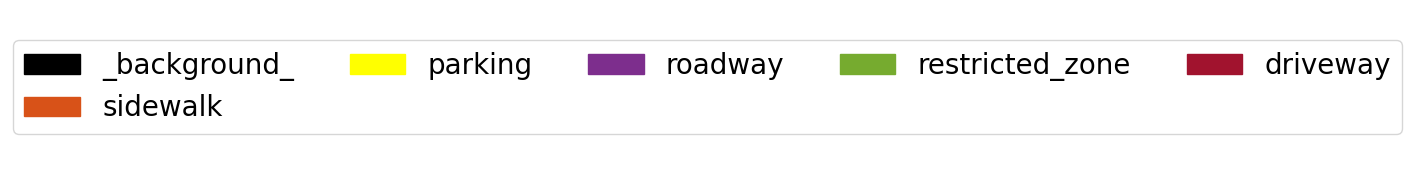

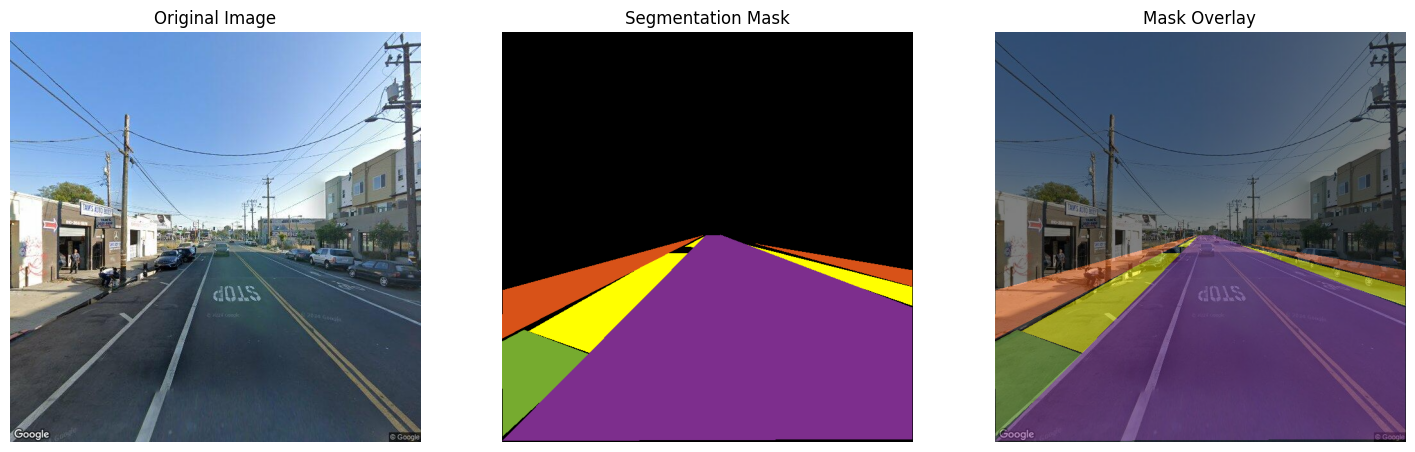

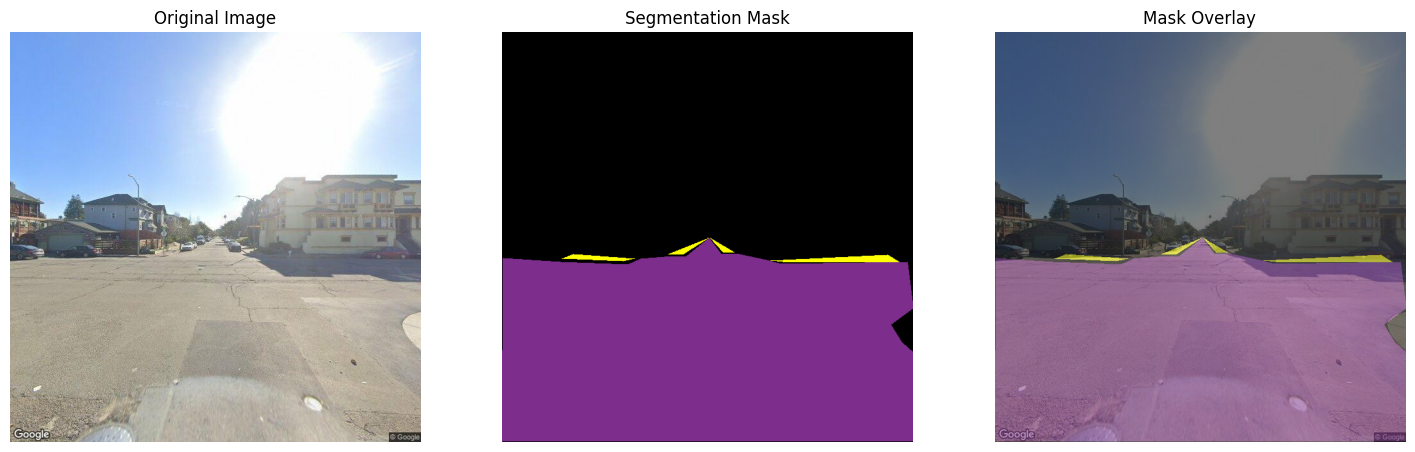

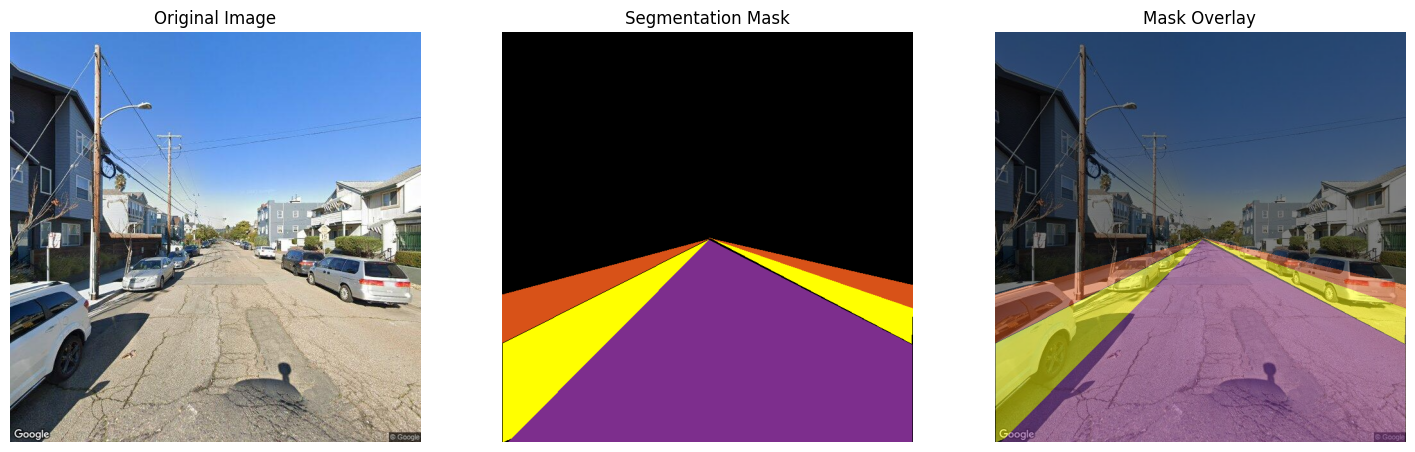

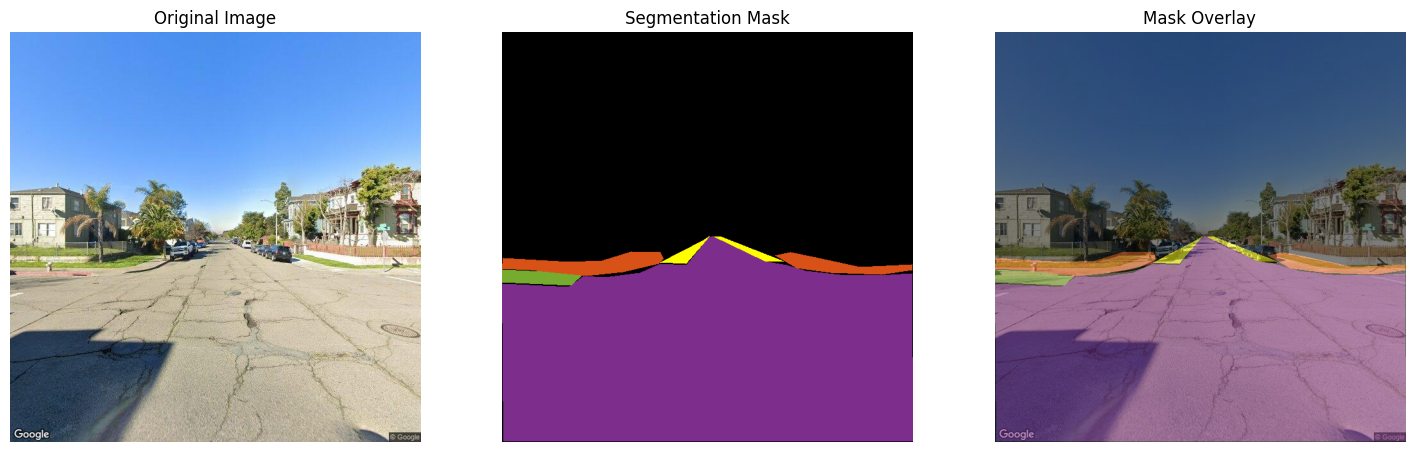

In [9]:
show_legend()
show_examples()

## 1.3 Checking the Distribution of Class Occurences

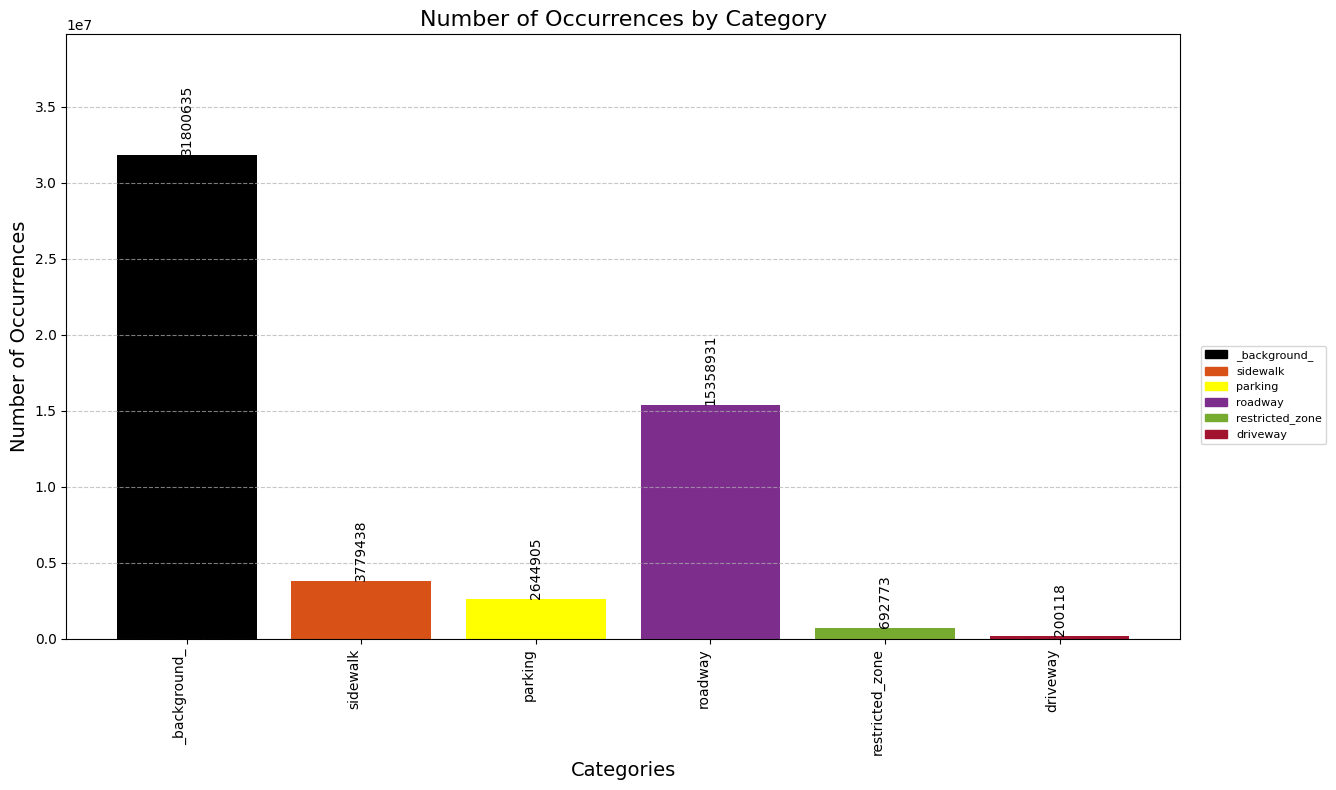

In [10]:
class_counts = np.zeros(len(id2label))

for example in dataset['train']:
    mask_np = np.asarray(example['label'])
    unique, counts = np.unique(mask_np, return_counts=True)
    for u, c in zip(unique, counts):
        class_counts[u] += c
        
labels = list(id2label.values())

# Normalize colors to be in the range [0, 1]
normalized_palette = [
    tuple(c / 255 for c in color)\
    for color in palette
]

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.bar(
    range(len(labels)), 
    class_counts, 
    color=[normalized_palette[i] for i in range(len(labels))]
)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, ha="right")

ax.set_xlabel("Categories", fontsize=14)
ax.set_ylabel("Number of Occurrences", fontsize=14)
ax.set_title("Number of Occurrences by Category", fontsize=16)

ax.grid(axis="y", linestyle="--", alpha=0.7)

# Adjust the y-axis limit
y_max = max(class_counts)
ax.set_ylim(0, y_max * 1.25)

for bar in bars:
    height = int(bar.get_height())
    # Adjust the text location
    offset = 10
    
    ax.text(
        bar.get_x() + bar.get_width() / 2.0, 
        height + offset, 
        f"{height}",
        ha="center", 
        va="bottom", 
        rotation=90, 
        fontsize=10, 
        color='black'
    )

fig.legend(
    handles=legend_patches, 
    loc='center left', 
    bbox_to_anchor=(1, 0.5), 
    ncol=1, 
    fontsize=8
)

plt.tight_layout()
plt.show()

## 1.4 Data Augmentation

In [12]:
import albumentations as A
from transformers import SegformerImageProcessor

image_processor = SegformerImageProcessor()

albumentations_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=30, p=0.7),
    A.RandomResizedCrop(size=(512, 512), scale=(0.8, 1.0), ratio=(0.75, 1.33), p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=25, val_shift_limit=20, p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.GaussNoise(p=0.4),
])

def train_transforms(example_batch):
    augmented = [
        albumentations_transform(
            image=np.array(image), 
            mask=np.array(label)
        )
        for image, label in zip(example_batch['image'], example_batch['label'])
    ]
    augmented_images = [item['image'] for item in augmented]
    augmented_masks  = [item['mask'] for item in augmented]
    inputs = image_processor(augmented_images, augmented_masks)
    return inputs

def val_transforms(example_batch):
    images = [x for x in example_batch['image']]
    masks  = [x for x in example_batch['label']]
    inputs = image_processor(images, masks)
    return inputs


# Set transforms
dataset['train'].set_transform(train_transforms)
dataset['test'].set_transform(val_transforms)

/home/moofy/Programming/parklet-vision/venv/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 2.1 Loading and Configuring the Model

In [13]:
from transformers import SegformerForSemanticSegmentation

pretrained_model_name = "nvidia/mit-b2"
model = SegformerForSemanticSegmentation.from_pretrained(
    pretrained_model_name,
    id2label=id2label,
    label2id=label2id
)

Loading weights: 100%|█████████████████████| 364/364 [00:00<00:00, 24173.90it/s]
[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.num_batche

In [14]:
from transformers import TrainingArguments

output_dir = "model-output"

training_args = TrainingArguments(
    output_dir=output_dir,
    learning_rate=6e-5,
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    save_total_limit=2,
    eval_strategy="steps",
    save_strategy="steps",
    save_steps=20,
    eval_steps=20,
    logging_steps=1,
    eval_accumulation_steps=5,
    load_best_model_at_end=True,
    report_to='wandb',
    remove_unused_columns=False
)

In [15]:
import evaluate
evaluate.logging.set_verbosity_error()

In [16]:
import torch
from torch import nn
import multiprocessing
import warnings

metric = evaluate.load("mean_iou")

def compute_metrics(eval_pred):
    with torch.no_grad():
        logits, labels = eval_pred
        logits_tensor = torch.from_numpy(logits)
        
        # scale the logits to the size of the label
        logits_tensor = nn.functional.interpolate(
            logits_tensor,
            size=labels.shape[-2:],
            mode="bilinear",
            align_corners=False,
        ).argmax(dim=1)

        # currently using _compute instead of compute: 
        # https://github.com/huggingface/evaluate/pull/328#issuecomment-1286866576
        pred_labels = logits_tensor.detach().cpu().numpy()
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            metrics = metric._compute(
                predictions=pred_labels,
                references=labels,
                num_labels=len(id2label),
                ignore_index=0,
                reduce_labels=image_processor.do_reduce_labels,
            )

        # add per category metrics as individual key-value pairs
        per_category_accuracy = metrics.pop("per_category_accuracy").tolist()
        per_category_iou = metrics.pop("per_category_iou").tolist()

        metrics.update({f"accuracy_{id2label[i]}": v for i, v in enumerate(per_category_accuracy)})
        metrics.update({f"iou_{id2label[i]}": v for i, v in enumerate(per_category_iou)})

        return metrics

## 2.3 Training

In [17]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test'],
    processing_class=image_processor,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /home/moofy/.netrc
wandb: Currently logged in as: moofy (moofy-university-of-british-columbia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/home/moofy/Programming/parklet-vision/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
trainer.save_model("model-output/best_model")
image_processor.save_pretrained("model-output/best_model")

## 3.1 Testing

In [ ]:
metrics = trainer.evaluate(dataset['test'])
metrics

## 3.2 Example Image Testing

In [ ]:
example_image = Image.open('example.png')
example_image

In [ ]:
from transformers import pipeline

segmentation_model = pipeline(
    "image-segmentation",
    model="model-output/best_model",
)

results = segmentation_model(example_image)

In [ ]:
example_image_array = np.array(example_image)
segmentation_map = np.zeros_like(example_image_array)

for result in results:
    mask = np.array(result['mask'])
    label = result['label']

    label_index = list(id2label.values()).index(label)

    color = palette[label_index]

    for c in range(3):
        segmentation_map[:, :, c] = np.where(mask, color[c], segmentation_map[:, :, c])

show_legend()
plt.figure(figsize=(10, 10))
plt.imshow(example_image_array)
plt.imshow(segmentation_map, alpha=0.5)
plt.axis('off')
plt.show()